In [4]:
import pandas as pd
import numpy as np
import math
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
# 1. Đọc và làm sạch dữ liệu
df = pd.read_csv('dga_data.csv')
df = df.dropna(subset=['domain']) # Xóa 2 dòng rỗng

# 2. Mã hóa nhãn
df['label'] = df['isDGA'].map({'dga': 1, 'legit': 0})

# 3. Rút trích đặc trưng (Feature Engineering)
# 3.1. Độ dài tên miền
df['domain_length'] = df['domain'].apply(len)

# 3.2. Tính Entropy (Độ ngẫu nhiên của chuỗi)
def calculate_entropy(text):
    if not text:
        return 0
    entropy = 0
    for x in set(text):
        p_x = float(text.count(x)) / len(text)
        entropy += - p_x * math.log2(p_x)
    return entropy
def vowel_consonant_ratio(domain):
    vowels = sum(1 for c in str(domain) if c in 'aeiou')
    consonants = sum(1 for c in str(domain) if c.isalpha() and c not in 'aeiou')
    # Cộng 1 ở mẫu số để tránh lỗi chia cho 0
    return vowels / (consonants + 1)

df['vcl_ratio'] = df['domain'].apply(vowel_consonant_ratio)
# 2. Tỷ lệ ký tự duy nhất
df['unique_char_ratio'] = df['domain'].apply(lambda x: len(set(str(x))) / len(str(x)))

# 3. Trích xuất đặc trưng N-grams (Bigram - nhóm 2 ký tự)
# Lấy 100 cặp ký tự phổ biến nhất làm 100 đặc trưng
vectorizer = CountVectorizer(analyzer='char', ngram_range=(2, 2), max_features=100)
ngram_features = vectorizer.fit_transform(df['domain'].astype(str)).toarray()

# Tạo DataFrame cho N-grams để dễ nhìn
ngram_df = pd.DataFrame(ngram_features, columns=vectorizer.get_feature_names_out())

# Nối các đặc trưng N-gram vào DataFrame ban đầu
df_final = pd.concat([df.reset_index(drop=True), ngram_df.reset_index(drop=True)], axis=1)
df['entropy'] = df['domain'].apply(calculate_entropy)

# 3.3. Số lượng chữ số
df['num_digits'] = df['domain'].apply(lambda x: sum(c.isdigit() for c in x))

# Xem thử kết quả
print(df_final.head())

  isDGA                      domain                            host  \
0   dga  6xzxsw3sokvg1tc752y1a6p0af  6xzxsw3sokvg1tc752y1a6p0af.com   
1   dga              glbtlxwwhbnpxs               glbtlxwwhbnpxs.ru   
2   dga              xxmamopyipbfpk               xxmamopyipbfpk.ru   
3   dga   zfd5szpi18i85wj9uy13l69rg   zfd5szpi18i85wj9uy13l69rg.net   
4   dga                jpqftymiuver                 jpqftymiuver.ru   

       subclass  label  domain_length  vcl_ratio  unique_char_ratio  ac  ad  \
0   gameoverdga      1             26   0.200000           0.807692   0   0   
1  cryptolocker      1             14   0.000000           0.714286   0   0   
2  cryptolocker      1             14   0.250000           0.714286   0   0   
3        newgoz      1             25   0.230769           0.760000   0   0   
4  cryptolocker      1             12   0.300000           1.000000   0   0   

   ...  th  ti  to  tr  ts  un  ur  us  ve  vi  
0  ...   0   0   0   0   0   0   0   0   0   0  


Số mẫu huấn luyện: 127998
Số mẫu kiểm thử: 32000

--- BÁO CÁO ĐÁNH GIÁ (CLASSIFICATION REPORT) ---
              precision    recall  f1-score   support

   Legit (0)       0.95      0.97      0.96     16000
     DGA (1)       0.96      0.95      0.96     16000

    accuracy                           0.96     32000
   macro avg       0.96      0.96      0.96     32000
weighted avg       0.96      0.96      0.96     32000



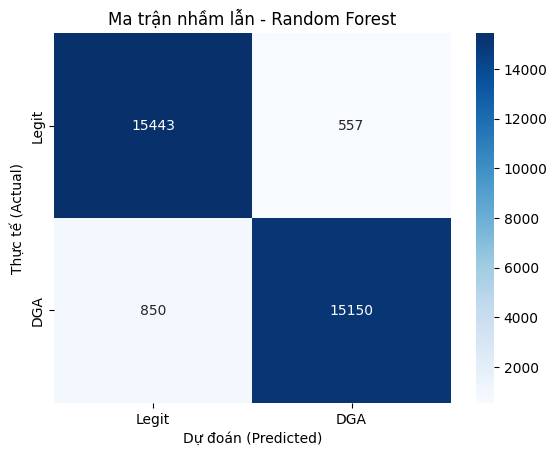

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
# 1. Tách Features (X) và Label (y)
# Bỏ đi các cột không phải dạng số (domain, host, subclass, isDGA)
X = df_final.drop(columns=['domain', 'host', 'subclass', 'isDGA', 'label'])
y = df_final['label']

# 2. Chia tập Train / Test (Tỷ lệ 80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Số mẫu huấn luyện: {X_train.shape[0]}")
print(f"Số mẫu kiểm thử: {X_test.shape[0]}")

# 3. Khởi tạo và Huấn luyện mô hình Random Forest
# n_estimators=100 nghĩa là tạo ra 100 cây quyết định
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 4. Dự đoán trên tập kiểm thử (Test)
y_pred = rf_model.predict(X_test)

# 5. Đánh giá kết quả
print("\n--- BÁO CÁO ĐÁNH GIÁ (CLASSIFICATION REPORT) ---")
print(classification_report(y_test, y_pred, target_names=['Legit (0)', 'DGA (1)']))

# 6. Vẽ Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legit', 'DGA'], yticklabels=['Legit', 'DGA'])
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.title('Ma trận nhầm lẫn - Random Forest')
plt.savefig('confusion_matrix.png') # Lưu ảnh để cho vào báo cáo

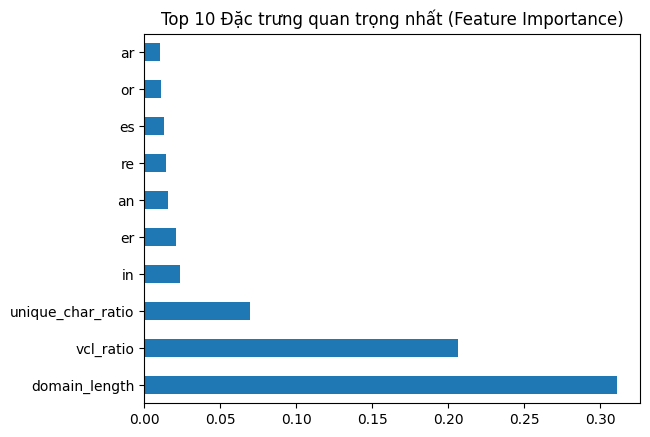

In [6]:
# Xem Top 10 đặc trưng quan trọng nhất
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Đặc trưng quan trọng nhất (Feature Importance)')
plt.savefig('feature_importance.png')

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Dự đoán trên tập kiểm thử (nếu bạn đã chạy lệnh này rồi thì bỏ qua)
# y_pred = rf_model.predict(X_test)

# --- TÍNH TOÁN CÁC ĐỘ ĐO (Tập trung vào lớp 1 - DGA) ---
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred) # Mặc định tính cho lớp 1
recall = recall_score(y_test, y_pred)       # Mặc định tính cho lớp 1
f1 = f1_score(y_test, y_pred)               # Mặc định tính cho lớp 1

# --- IN KẾT QUẢ ĐỂ ĐƯA VÀO BÁO CÁO ---
print("=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST ===")
print(f"1. Accuracy  (Độ chính xác tổng thể): {accuracy * 100:.2f}%")
print(f"2. Precision (Độ chính xác nhãn DGA) : {precision * 100:.2f}%")
print(f"3. Recall    (Độ bao phủ nhãn DGA)   : {recall * 100:.2f}%")
print(f"4. F1-score  (Độ cân bằng P & R)     : {f1 * 100:.2f}%")

=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST ===
1. Accuracy  (Độ chính xác tổng thể): 95.60%
2. Precision (Độ chính xác nhãn DGA) : 96.45%
3. Recall    (Độ bao phủ nhãn DGA)   : 94.69%
4. F1-score  (Độ cân bằng P & R)     : 95.56%
